### Digital / Barrier Option: Monte Carlo 가격과 Greeks

UFEA 6주차 실습과제 해답본을 설명용으로 정리한 노트북입니다. 함수는 `src/mc_exotics/` 에 있고, 여기서는 불러서 결과를 확인합니다.

네 섹션은 2×2 구조입니다.

| | 가격 | Greeks |
|---|---|---|
| payoff가 $S_T$ 만 봄 | 1. digital | 2. digital |
| payoff가 경로 전체를 봄 | 3. barrier | 4. barrier |

검증 기준은 두 가지입니다. closed form이 있는 곳에서는 Monte Carlo 추정치가 표준오차 몇 배만큼 떨어져 있는지(`z`)를 봅니다. closed form이 없는 곳에서는 같은 경로 위에서 성립해야 하는 항등식의 잔차를 봅니다.

In [1]:
from functools import partial
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from mc_exotics import (
    barrier_prices, bs_call, bs_call_greeks, digital_call_analytic, digital_call_greeks,
    digital_call_mc, digital_price, down_in_call_payoff, down_out_call_payoff, fd_greeks,
    mc_stats, simulate_paths, simulate_terminal, vanilla_call_payoff,
)

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3, "font.size": 9})
FIG_DIR = Path("..") / "figures"
FIG_DIR.mkdir(exist_ok=True)

# Contract and market (no dividends)
S0, K = 100.0, 100.0
r, sigma = 0.03, 0.20
T = 1.0
B = 85.0

# Simulation
SEED = 20260828
N_TERMINAL = 500000          # sections 1-2
N_PATH = 20000               # sections 3-4
N_STEPS = 252                # daily barrier monitoring

# Finite differences
H_SPOT = 3.0
H_VOL = 0.02

S_GRID = np.arange(70.0, 130.1, 2.0)

print(f"S0={S0}  K={K}  r={r}  sigma={sigma}  T={T}  B={B}")
print(f"paths: terminal {N_TERMINAL:,} / full {N_PATH:,} x {N_STEPS} steps")
print(f"bump: dS={H_SPOT}, d(sigma)={H_VOL}, seed={SEED}")

S0=100.0  K=100.0  r=0.03  sigma=0.2  T=1.0  B=85.0
paths: terminal 500,000 / full 20,000 x 252 steps
bump: dS=3.0, d(sigma)=0.02, seed=20260828


In [2]:
def show(label, value, se=None, ref=None, ref_label="closed form"):
    """Print one aligned result line with relative error and z when available."""
    line = f"{label} {value:>12.6f}"
    if se is not None:
        line += f" ± {se:.6f}"
    if ref is not None:
        line += f"   |  {ref_label} {ref:>12.6f}"
        line += f"   rel.err {abs(value / ref - 1):.2%}" if ref else ""
        if se:
            line += f"   z={(value - ref) / se:+.2f}"
    print(line)

### 1. Monte Carlo로 digital option 가격 구하기

옵션 가격은 risk neutral measure $\mathbb{Q}$ 하의 할인 기대값입니다.

$$V_0 = e^{-rT}\,\mathbb{E}^{\mathbb{Q}}\big[\,\text{payoff}\,\big]$$

$\mathbb{Q}$ 하에서 할인 주가가 Martingale이어야 하므로 drift는 $r$ 이고 $\mathbb{E}^{\mathbb{Q}}[S_T] = S_0e^{rT}$ 입니다. GBM은 closed form이 있어서 만기값만 필요하면 난수 하나로 바로 만기까지 갑니다.

$$S_T = S_0 \exp\!\Big[\big(r - \tfrac{1}{2}\sigma^2\big)T + \sigma\sqrt{T}\,Z\Big]$$

In [3]:
rng = np.random.default_rng(SEED)
Z = rng.standard_normal(N_TERMINAL)
S_T = simulate_terminal(S0, r, sigma, T, Z)
exact_mean = S0 * np.exp(r * T)

print(f"shape {S_T.shape},  min {S_T.min():.2f},  max {S_T.max():.2f}")
show("E[S_T]", *mc_stats(S_T), exact_mean, "S0*exp(rT)")

shape (500000,),  min 39.93,  max 261.12
E[S_T]   103.011985 ± 0.029398   |  S0*exp(rT)   103.045453   rel.err 0.03%   z=-1.14


cash-or-nothing digital call은 만기에 $S_T > K$ 이면 1을 줍니다. payoff가 indicator이므로 기대값은 확률이고, 가격은 Black-Scholes의 $N(d_2)$ 에 할인계수를 곱한 값입니다.

$$V_0 = e^{-rT}\,\mathbb{Q}(S_T > K) = e^{-rT}N(d_2)$$

In [4]:
price_mc, se_mc = digital_call_mc(S_T, K, r, T)
price_exact = digital_call_analytic(S0, K, r, sigma, T)

show("digital call", price_mc, se_mc, price_exact, "e^{-rT}N(d2)")
print(f"95% CI : [{price_mc - 1.96*se_mc:.6f}, {price_mc + 1.96*se_mc:.6f}]")

digital call     0.503815 ± 0.000686   |  e^{-rT}N(d2)     0.504572   rel.err 0.15%   z=-1.11
95% CI : [0.502471, 0.505159]


가격 곡선은 모든 격자점에서 같은 난수 `Z` 를 씁니다. 격자점마다 새로 뽑으면 곡선이 노이즈에 묻힙니다.

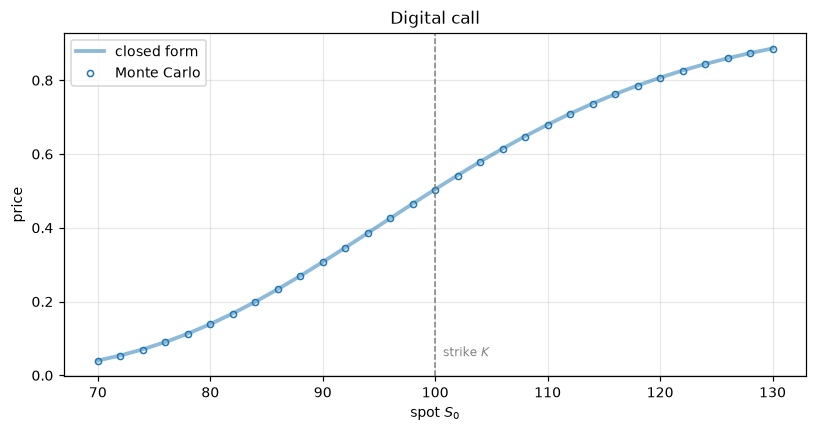

In [5]:
price_curve_mc = np.array([digital_call_mc(simulate_terminal(s, r, sigma, T, Z), K, r, T)[0]
                           for s in S_GRID])
price_curve_exact = digital_call_analytic(S_GRID, K, r, sigma, T)

fig, ax = plt.subplots(figsize=(7.5, 4.0))
ax.plot(S_GRID, price_curve_exact, "-", lw=2.5, alpha=0.5, color="tab:blue", label="closed form")
ax.plot(S_GRID, price_curve_mc, "o", ms=4, color="tab:blue", mfc="none", label="Monte Carlo")
ax.axvline(K, color="grey", ls="--", lw=1)
ax.text(K + 0.7, 0.05, "strike $K$", color="grey", fontsize=8)
ax.set_xlabel("spot $S_0$")
ax.set_ylabel("price")
ax.set_title("Digital call")
ax.legend()
plt.tight_layout()
plt.show()

### 2. 유한차분법으로 digital option Greeks 구하기

closed form이 없을 때는 값을 여러 번 매겨서 차분합니다. 편향이 작은 중심차분을 씁니다.

$$\Delta \approx \frac{V(S_0+h) - V(S_0-h)}{2h}, \qquad
\Gamma \approx \frac{V(S_0+h) - 2V(S_0) + V(S_0-h)}{h^2}, \qquad
\mathcal{V} \approx \frac{V(\sigma+h_\sigma) - V(\sigma-h_\sigma)}{2h_\sigma}$$

$V$ 가 Monte Carlo 추정치이면 다섯 번의 재평가에 같은 난수를 넘겨야 합니다(common random numbers). 매번 새로 뽑으면 분자에 독립적인 오차 두 개가 남고, 그것을 작은 $h$ 로 나누면서 노이즈가 커집니다. `fd_greeks` 는 `price_fn(spot, vol, Z)` 형태의 함수를 받아 같은 `Z` 를 다섯 번 넘깁니다.

In [6]:
digital_pricer = partial(digital_price, K=K, r=r, T=T)
greeks_mc = fd_greeks(digital_pricer, S0, sigma, Z, H_SPOT, H_VOL)
greeks_exact = digital_call_greeks(S0, K, r, sigma, T)

for name, mc, exact in zip(("delta", "gamma", "vega"), greeks_mc, greeks_exact):
    show(f"digital {name}", mc, None, exact)

digital delta     0.019257   |  closed form     0.019333   rel.err 0.40%
digital gamma    -0.000275   |  closed form    -0.000242   rel.err 13.60%
digital vega    -0.482214   |  closed form    -0.483335   rel.err 0.23%


digital gamma는 참값이 0.0002 수준이라 한 점의 상대오차는 크게 나옵니다. 판단은 아래 곡선 전체로 합니다.

digital delta  RMSE / curve amplitude = 0.6%
digital gamma  RMSE / curve amplitude = 3.8%
digital vega   RMSE / curve amplitude = 0.4%


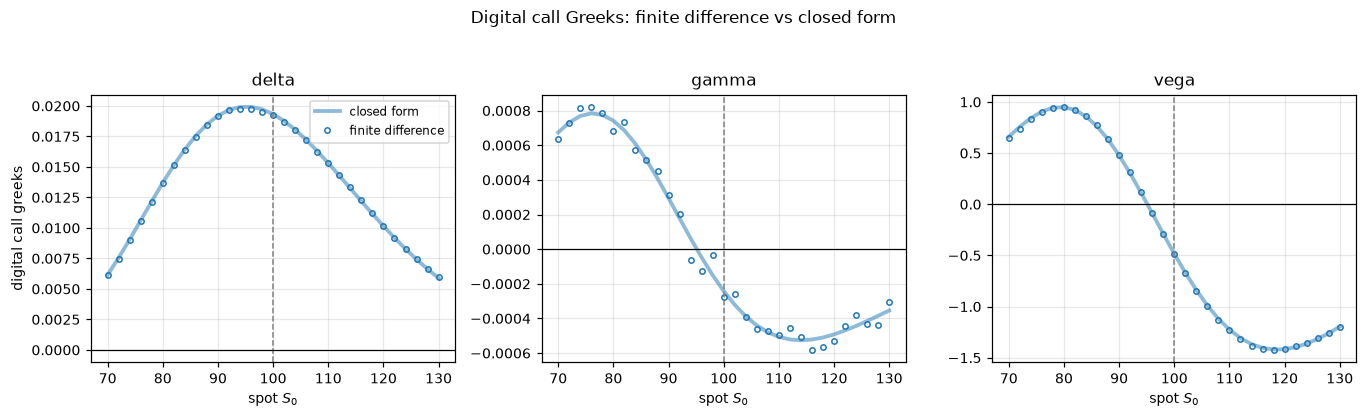

In [7]:
greeks_curve_mc = np.array([fd_greeks(digital_pricer, s, sigma, Z, H_SPOT, H_VOL) for s in S_GRID])
greeks_curve_exact = np.column_stack(digital_call_greeks(S_GRID, K, r, sigma, T))

amplitude = greeks_curve_exact.max(axis=0) - greeks_curve_exact.min(axis=0)
rmse = np.sqrt(((greeks_curve_mc - greeks_curve_exact) ** 2).mean(axis=0))
for name, a, e in zip(("delta", "gamma", "vega"), amplitude, rmse):
    print(f"digital {name:5s}  RMSE / curve amplitude = {e / a:.1%}")

fig, axes = plt.subplots(1, 3, figsize=(12.5, 3.6))
for ax, j, name in zip(axes, range(3), ("delta", "gamma", "vega")):
    ax.plot(S_GRID, greeks_curve_exact[:, j], "-", lw=2.5, alpha=0.5, color="tab:blue",
            label="closed form")
    ax.plot(S_GRID, greeks_curve_mc[:, j], "o", ms=3.5, color="tab:blue", mfc="none",
            label="finite difference")
    ax.axvline(K, color="grey", ls="--", lw=1)
    ax.axhline(0, color="k", lw=0.8)
    ax.set_xlabel("spot $S_0$")
    ax.set_title(name)
axes[0].set_ylabel("digital call greeks")
axes[0].legend(fontsize=8)
fig.suptitle("Digital call Greeks: finite difference vs closed form", y=1.04)
plt.tight_layout()
fig.savefig(FIG_DIR / "digital_greeks.png", bbox_inches="tight")
plt.show()

### 3. Monte Carlo로 barrier option 가격 구하기

지급액이 만기까지의 정보로 정해지기만 하면 가격은 여전히 할인 기대값입니다. $g(S_T)$ 가 $G(\text{경로 전체})$ 로 바뀔 뿐입니다.

$$V_0 = e^{-rT}\,\mathbb{E}^{\mathbb{Q}}\Big[\,G\big(\{S_t\}_{0\le t\le T}\big)\,\Big]$$

경로는 로그 증분의 누적합으로 만듭니다. 배리어는 실제 계약처럼 일별 종가로 판정합니다.

$$\Delta \log S = \Big(r - \tfrac12\sigma^2\Big)\Delta t + \sigma\sqrt{\Delta t}\,Z_i,
\qquad \Delta t = T/252$$

shape (20000, 253)
first column min / max : 100.0000 / 100.0000
path array size : 40 MB
E[S_T]  (paths)   103.105418 ± 0.146192   |  S0*exp(rT)   103.045453   rel.err 0.06%   z=+0.41


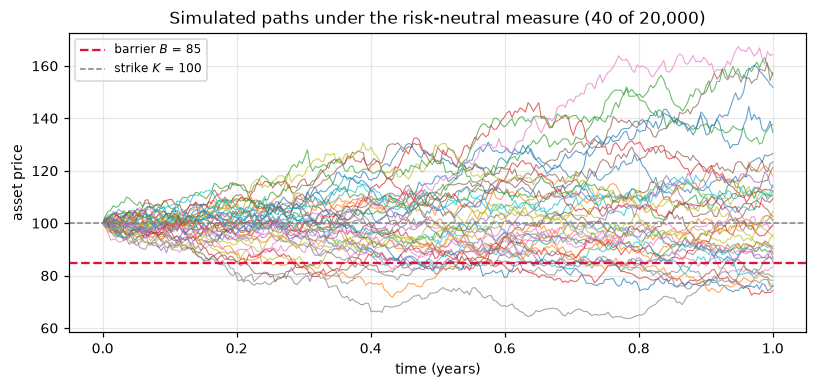

In [8]:
rng_path = np.random.default_rng(SEED + 10)
Z_path = rng_path.standard_normal((N_PATH, N_STEPS))
S_paths = simulate_paths(S0, r, sigma, T, Z_path)

print(f"shape {S_paths.shape}")
print(f"first column min / max : {S_paths[:, 0].min():.4f} / {S_paths[:, 0].max():.4f}")
print(f"path array size : {S_paths.nbytes / 1e6:.0f} MB")
show("E[S_T]  (paths)", *mc_stats(S_paths[:, -1]), exact_mean, "S0*exp(rT)")

fig, ax = plt.subplots(figsize=(7.5, 3.6))
ax.plot(np.linspace(0, T, N_STEPS + 1), S_paths[:40].T, lw=0.7, alpha=0.7)
ax.axhline(B, color="crimson", lw=1.5, ls="--", label=f"barrier $B$ = {B:.0f}")
ax.axhline(K, color="grey", lw=1, ls="--", label=f"strike $K$ = {K:.0f}")
ax.set_xlabel("time (years)")
ax.set_ylabel("asset price")
ax.set_title("Simulated paths under the risk-neutral measure (40 of 20,000)")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

down-and-out call은 관찰 기간 내내 배리어 위에 있어야 살아남고, down-and-in call은 한 번이라도 배리어에 닿아야 생깁니다.

$$\text{knock-out} : (S_T-K)^+ \cdot \mathbf{1}\{\textstyle\min_t S_t > B\},
\qquad
\text{knock-in} : (S_T-K)^+ \cdot \mathbf{1}\{\textstyle\min_t S_t \le B\}$$

모든 경로는 둘 중 하나에서만 payoff를 받으므로 contractual equation이 경로별로 성립합니다.

$$C_{\text{down-and-out}} + C_{\text{down-and-in}} = C_{\text{vanilla}}$$

두 payoff는 코드에서 각자의 조건으로 따로 정의했습니다. vanilla에서 빼서 정의하면 이 식이 정의상 성립해 버려 검증이 되지 않습니다. 같은 경로로 셋을 계산하므로 잔차는 부동소수점 수준이어야 합니다.

In [9]:
discount = np.exp(-r * T)
payoff_out = down_out_call_payoff(S_paths, K, B)
payoff_in = down_in_call_payoff(S_paths, K, B)
payoff_van = vanilla_call_payoff(S_paths, K)
max_gap = np.abs(payoff_out + payoff_in - payoff_van).max()

price_out, se_out = mc_stats(discount * payoff_out)
price_in, se_in = mc_stats(discount * payoff_in)
price_van, se_van = mc_stats(discount * payoff_van)

show("down-and-out call", price_out, se_out)
show("down-and-in  call", price_in, se_in)
show("sum", price_out + price_in)
show("vanilla call (same paths)", price_van, se_van)
print(f"\nmax per-path parity gap : {max_gap:.3e}")
print(f"knock-out ratio : {(S_paths.min(axis=1) <= B).mean():.2%}")

down-and-out call     8.965702 ± 0.098961
down-and-in  call     0.452507 ± 0.019277
sum     9.418209
vanilla call (same paths)     9.418209 ± 0.098788

max per-path parity gap : 0.000e+00
knock-out ratio : 38.17%


vanilla call은 closed form이 있으므로 같은 경로의 Monte Carlo 가격과 비교해 경로 생성을 확인합니다.

In [10]:
bs_price = bs_call(S0, K, r, sigma, T)
show("vanilla call (MC)", price_van, se_van, bs_price, "Black-Scholes")

vanilla call (MC)     9.418209 ± 0.098788   |  Black-Scholes     9.413403   rel.err 0.05%   z=+0.05


`barrier_prices` 는 경로를 한 번 만들고 세 가격을 함께 돌려줍니다. 모든 격자점이 같은 `Z_path` 를 쓰므로 곡선 위에서도 contractual equation이 성립합니다.

shape (31, 3)  =  (grid points 31, products 3)
max |(out + in) - vanilla| over the grid : 7.105e-15


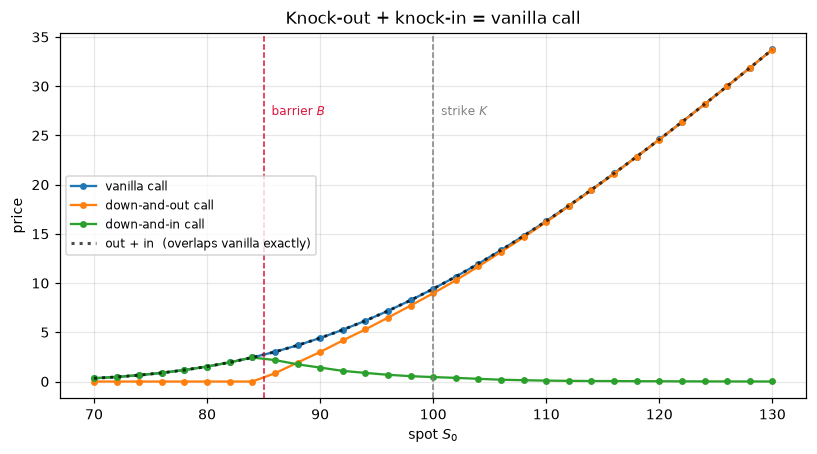

In [11]:
barrier_pricer = partial(barrier_prices, K=K, B=B, r=r, T=T)
price_curves = np.array([barrier_pricer(s, sigma, Z_path) for s in S_GRID])
print(f"shape {price_curves.shape}  =  (grid points {len(S_GRID)}, products 3)")
print(f"max |(out + in) - vanilla| over the grid : "
      f"{np.abs(price_curves[:, 1] + price_curves[:, 2] - price_curves[:, 0]).max():.3e}")

fig, ax = plt.subplots(figsize=(7.5, 4.2))
for j, name in enumerate(("vanilla call", "down-and-out call", "down-and-in call")):
    ax.plot(S_GRID, price_curves[:, j], "-", marker="o", ms=3.5, lw=1.5, label=name)
ax.plot(S_GRID, price_curves[:, 1] + price_curves[:, 2], "k:", lw=2, alpha=0.7,
        label="out + in  (overlaps vanilla exactly)")
ax.axvline(B, color="crimson", ls="--", lw=1)
ax.axvline(K, color="grey", ls="--", lw=1)
ax.text(B + 0.7, 27, "barrier $B$", color="crimson", fontsize=8)
ax.text(K + 0.7, 27, "strike $K$", color="grey", fontsize=8)
ax.set_xlabel("spot $S_0$")
ax.set_ylabel("price")
ax.set_title("Knock-out + knock-in = vanilla call")
ax.legend(fontsize=8)
plt.tight_layout()
fig.savefig(FIG_DIR / "barrier_prices.png", bbox_inches="tight")
plt.show()

### 4. 유한차분법으로 barrier option Greeks 구하기

barrier option은 여기서 Greeks 공식을 쓰지 않습니다. `barrier_prices` 가 `price_fn(spot, vol, Z)` 형태이므로 Section 2의 `fd_greeks` 를 그대로 넣으면 됩니다. 가격이 길이 3 배열이므로 Greeks도 세 상품에 대해 한 번에 나옵니다.

미분은 선형이라 contractual equation은 Greeks에서도 성립합니다.

$$\Delta_{\text{out}} + \Delta_{\text{in}} = \Delta_{\text{vanilla}},
\qquad \Gamma_{\text{out}} + \Gamma_{\text{in}} = \Gamma_{\text{vanilla}},
\qquad \mathcal{V}_{\text{out}} + \mathcal{V}_{\text{in}} = \mathcal{V}_{\text{vanilla}}$$

In [12]:
delta, gamma, vega = fd_greeks(barrier_pricer, S0, sigma, Z_path, H_SPOT, H_VOL)
greeks = np.array([delta, gamma, vega])          # shape (3 Greeks, 3 products)
products = ("vanilla", "down-and-out", "down-and-in")

print(f"{'':>14}{'delta':>12}{'gamma':>12}{'vega':>12}")
for j, name in enumerate(products):
    print(f"{name:>14}{delta[j]:>12.5f}{gamma[j]:>12.5f}{vega[j]:>12.4f}")
print(f"{'out + in':>14}{delta[1]+delta[2]:>12.5f}{gamma[1]+gamma[2]:>12.5f}{vega[1]+vega[2]:>12.4f}")

                     delta       gamma        vega
       vanilla     0.59948     0.01955     38.5824
  down-and-out     0.64639     0.01646     28.8876
   down-and-in    -0.04692     0.00309      9.6948
      out + in     0.59948     0.01955     38.5824


In [13]:
bs_greeks_exact = bs_call_greeks(S0, K, r, sigma, T)
for name, mc, exact in zip(("delta", "gamma", "vega"), greeks[:, 0], bs_greeks_exact):
    show(f"vanilla {name}", mc, None, exact, "Black-Scholes")

parity_gap = np.abs(greeks[:, 1] + greeks[:, 2] - greeks[:, 0]).max()
print(f"\nmax Greeks parity gap : {parity_gap:.3e}")

vanilla delta     0.599478   |  Black-Scholes     0.598706   rel.err 0.13%
vanilla gamma     0.019550   |  Black-Scholes     0.019333   rel.err 1.12%
vanilla vega    38.582402   |  Black-Scholes    38.666812   rel.err 0.22%

max Greeks parity gap : 2.842e-14


격자점 하나마다 경로 20,000개를 다섯 번 새로 만들기 때문에 아래 셀이 가장 오래 걸립니다.

In [14]:
greeks_grid = np.array([fd_greeks(barrier_pricer, s, sigma, Z_path, H_SPOT, H_VOL) for s in S_GRID])
print(f"shape {greeks_grid.shape}  =  (grid points {len(S_GRID)}, Greeks 3, products 3)")
print(f"max |(out + in) - vanilla| over the grid : "
      f"{np.abs(greeks_grid[:, :, 1] + greeks_grid[:, :, 2] - greeks_grid[:, :, 0]).max():.3e}")

shape (31, 3, 3)  =  (grid points 31, Greeks 3, products 3)
max |(out + in) - vanilla| over the grid : 3.766e-13


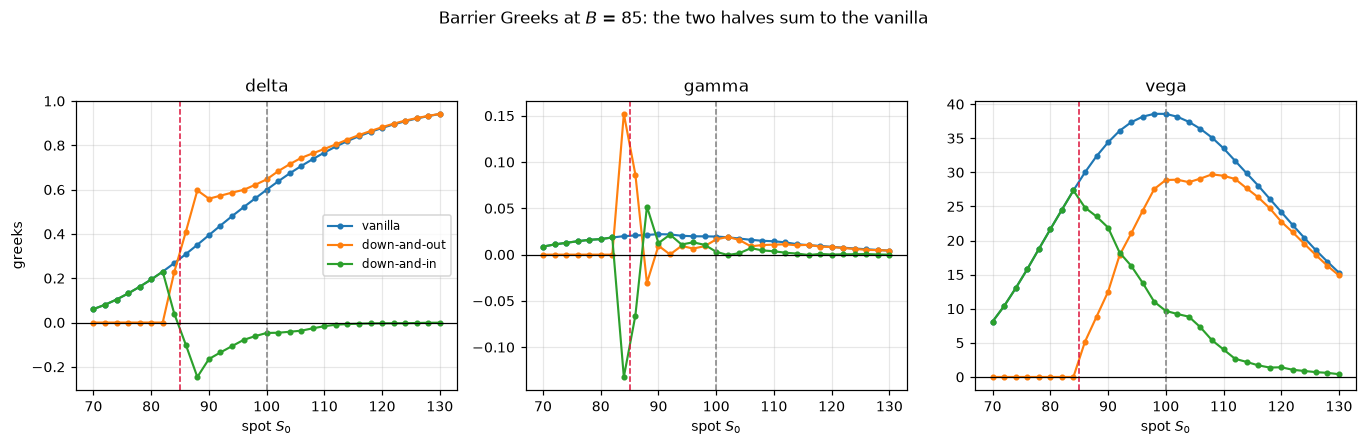

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(12.5, 3.8))
colors = ("tab:blue", "tab:orange", "tab:green")

for ax, j, name in zip(axes, range(3), ("delta", "gamma", "vega")):
    for k, (product, color) in enumerate(zip(products, colors)):
        ax.plot(S_GRID, greeks_grid[:, j, k], "-o", ms=3, lw=1.4, color=color, label=product)
    ax.axvline(B, color="crimson", ls="--", lw=1)
    ax.axvline(K, color="grey", ls="--", lw=1)
    ax.axhline(0, color="k", lw=0.8)
    ax.set_xlabel("spot $S_0$")
    ax.set_title(name)

axes[0].set_ylabel("greeks")
axes[0].legend(fontsize=8)
fig.suptitle("Barrier Greeks at $B$ = 85: the two halves sum to the vanilla", y=1.05)
plt.tight_layout()
fig.savefig(FIG_DIR / "barrier_greeks.png", bbox_inches="tight")
plt.show()

그림에서 볼 것

1. vanilla(파랑)는 세 Greeks 모두 매끄럽습니다. gamma 패널에서 파란 곡선이 평평해 보이는 것은 배리어 근처의 스파이크가 훨씬 크기 때문입니다.
2. down-and-out(주황)은 배리어 근처에서 delta가 급하게 꺾이고 gamma가 튑니다. 배리어에 닿으면 계약이 사라지므로 가격이 그 지점에서 0으로 눌립니다. gamma가 크면 조금만 움직여도 헤지 수량을 크게 바꿔야 하므로 배리어 근처에서는 dynamic replication 비용이 커집니다.
3. down-and-in(초록)은 그 나머지입니다. 두 곡선을 더하면 항상 파란 곡선이 됩니다.
4. 배리어에서 멀리 위쪽으로 가면 knock-in 확률이 사라져 down-and-out은 vanilla에 가까워지고 down-and-in의 Greeks는 0으로 갑니다.